## TF-IDF representation evaluation

In [1]:
from utils.ml import tokenize, load_data, data_dir, evaluate_clustering_model
import matplotlib.pyplot as plt

In [2]:
df = load_data(data_dir)
sequences, tokens = tokenize(df)

TOKENIZED DF:
+----+-----+---+-----+-------+----------+--------------------+
|year|month|day|order|country|session ID|            sequence|
+----+-----+---+-----+-------+----------+--------------------+
|2008|    4|  1|    9|     29|         1|[120, 168, 197, 8...|
|2008|    4|  1|   10|     29|         2|[143, 55, 183, 27...|
+----+-----+---+-----+-------+----------+--------------------+
only showing top 2 rows

TOKEN INFO: 
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|page 1 (main category)|page 2 (clothing model)|colour|location|model photography|price|price 2|page| id|
+----------------------+-----------------------+------+--------+-----------------+-----+-------+----+---+
|                     1|                     A5|     3|       2|                1|   43|      2|   1|  0|
|                     3|                    C30|     2|       4|                2|   28|      2|   2|  1|
+----------------------+----------------

### Count Vectorizer + IDF
Normalization for evaluation stability

In [3]:
from pyspark.ml.feature import CountVectorizer, IDF, Normalizer
from pyspark.ml import Pipeline
vocab_size = tokens.count()
cv = CountVectorizer(vocabSize=vocab_size, inputCol="sequence", outputCol="bow")
idf = IDF(inputCol= "bow", outputCol="tf-idf")
norm = Normalizer(inputCol="tf-idf", outputCol="unit_norm")
stages = [cv, idf, norm]
tf_idf = Pipeline(stages=stages).fit(sequences)
vectorized = tf_idf.transform(sequences)
vectorized.show(5)

+----+-----+---+-----+-------+----------+--------------------+--------------------+--------------------+--------------------+
|year|month|day|order|country|session ID|            sequence|                 bow|              tf-idf|           unit_norm|
+----+-----+---+-----+-------+----------+--------------------+--------------------+--------------------+--------------------+
|2008|    4|  1|    9|     29|         1|[120, 168, 197, 8...|(218,[0,19,28,33,...|(218,[0,19,28,33,...|(218,[0,19,28,33,...|
|2008|    4|  1|   10|     29|         2|[143, 55, 183, 27...|(218,[3,8,14,31,5...|(218,[3,8,14,31,5...|(218,[3,8,14,31,5...|
|2008|    4|  1|    6|     21|         3|[87, 74, 11, 188,...|(218,[25,28,44,61...|(218,[25,28,44,61...|(218,[25,28,44,61...|
|2008|    4|  1|    4|     21|         4|    [90, 4, 74, 166]|(218,[61,78,111,1...|(218,[61,78,111,1...|(218,[61,78,111,1...|
|2008|    4|  1|    1|      9|         5|                [62]|    (218,[73],[1.0])|(218,[73],[3.5430...|    (218,[73],

### Evaluation (cosine distance)

In [4]:
results = {"K-Means": [], "Bisecting KMeans": []}
from pyspark.ml.clustering import BisectingKMeans, KMeans
results["K-Means"].append(evaluate_clustering_model(KMeans(maxIter=30), vectorized, range(2, 21), features_col="unit_norm", distance = "cosine"))
print("K-Means: done.")
results["Bisecting KMeans"].append(evaluate_clustering_model(BisectingKMeans(maxIter=50), vectorized, range(2, 21), features_col="unit_norm", distance = "cosine"))
print("Bi-Means: done.")

K-Means: done.
Bi-Means: done.


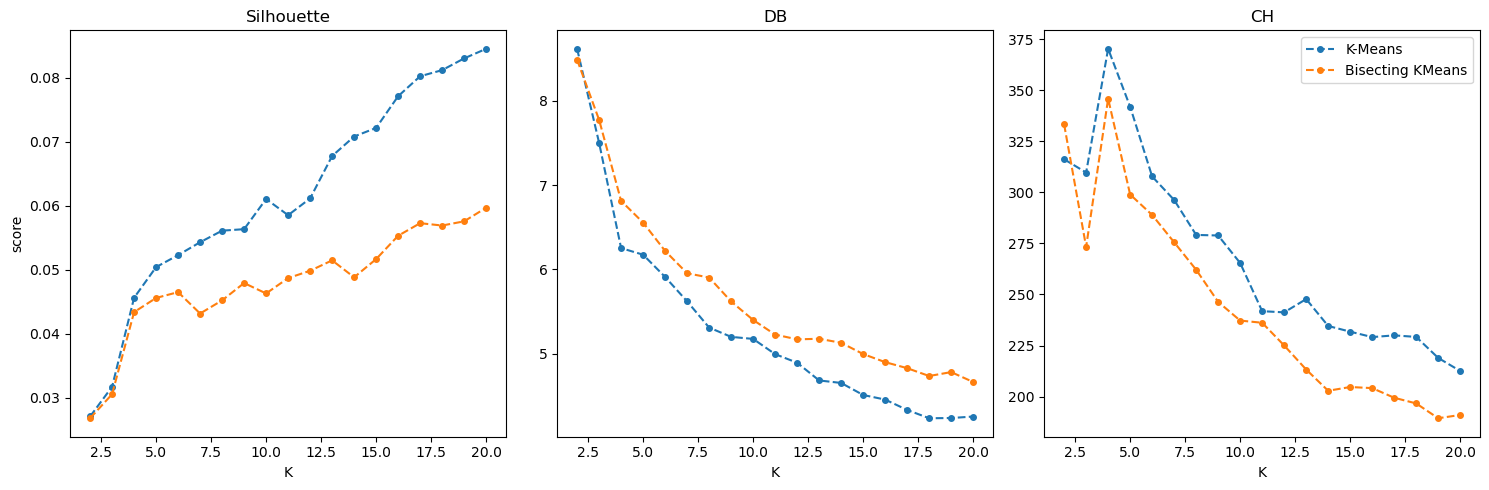

In [5]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharex=False)
models = list(results.keys())
scores = ["Silhouette", "DB", "CH"]
for r in range(1):
    for m in models:
        ax[0].plot(results[m][r]["N_K"], results[m][r]["silouhette"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[1].plot(results[m][r]["N_K"], results[m][r]["davies_bouldin"], label= m, linestyle = "--", marker = "o", markersize = 4)
        ax[2].plot(results[m][r]["N_K"], results[m][r]["calinski_harabasz"], label= m, linestyle = "--", marker = "o", markersize = 4)
    for c in range(3):
        ax[c].set_xlabel("K")
        if r == 0:
            ax[c].set_title(scores[c])
        if c == 0:
            ax[c].set_ylabel(f"score")
        if c == 2:
            ax[c].legend()
plt.tight_layout()
plt.show()

TODO: Despite scores are not very promising it is still reasonable to inspect resulting clusters.